# 19. Final baseline classification model

This notebook creates the **demographic-only baseline classification model** requested during the manuscript revision.

Purpose:

- Use the same train/test split as the CNN analyses.
- Use only the demographic/body-mass variables already included in the CNN metadata branch:
  - `RIAGENDR` = sex
  - `RIDAGEYR` = age
  - `BMXWT` = body mass
- Fit a simple logistic regression model.
- Evaluate it once on the held-out test set.
- Save the final test-set metrics and predictions.

Outcome:

- `TARGET_BINARY = 0`: normal bone status
- `TARGET_BINARY = 1`: osteopenia/osteoporosis


## 1. Imports and settings

In [1]:
import os
import platform
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import sklearn

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Adjust this path if the CSV files are stored elsewhere.
DATA_DIR = "."

# Output files will be saved here.
OUTPUT_DIR = "."

BASELINE_FEATURES = ["RIAGENDR", "RIDAGEYR", "BMXWT"]

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.11.3
NumPy: 1.26.3
pandas: 2.1.4
scikit-learn: 1.8.0


## 2. Load the existing train/test split

This notebook assumes that the following files already exist from the preprocessing pipeline:

- `X_train.csv`
- `X_test.csv`
- `y_train.csv`
- `y_test.csv`

These are the same split files used in the original machine-learning notebooks and should correspond to the 80/20 split used in the CNN analysis.


In [2]:
X_train_full = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_test_full = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))

y_train_df = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

# Convert the target files to 1D arrays.
# This works whether y_train.csv has one unnamed column or a named TARGET_BINARY column.
y_train = y_train_df.squeeze().to_numpy()
y_test = y_test_df.squeeze().to_numpy()

print("X_train shape:", X_train_full.shape)
print("X_test shape:", X_test_full.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_full.head()


X_train shape: (2003, 9)
X_test shape: (501, 9)
y_train shape: (2003,)
y_test shape: (501,)


,SEQN,RIAGENDR,RIDAGEYR,BMXWT,PAXMINSB,PAXMINLPA,PAXMINMPA,PAXMINVPA,PAXMINVVPA
0,76988.0,1.0,67.0,68.3,55.180460,271.081575,226.268674,20.398862,0.425658
1,82083.0,2.0,57.0,67.4,54.249962,349.396124,403.947424,111.523810,11.183867
2,75435.0,2.0,63.0,60.3,75.901543,298.740069,458.557302,63.265076,2.150472
3,76741.0,2.0,68.0,70.1,84.972456,257.353975,277.324868,45.859348,2.212542
4,78834.0,2.0,56.0,57.1,48.954254,330.458856,458.479079,84.496932,5.680614


## 3. Basic checks

We keep `SEQN` separately only for saved predictions. It is **not** used as a predictor.


In [3]:
# Keep participant identifiers for the predictions file, if available.
test_seqn = X_test_full["SEQN"].copy() if "SEQN" in X_test_full.columns else pd.Series(np.arange(len(X_test_full)), name="row_id")

# Check that the required baseline predictors are available.
missing_features = [col for col in BASELINE_FEATURES if col not in X_train_full.columns]

if missing_features:
    raise ValueError(f"Missing required baseline features: {missing_features}")

# Select only the demographic/body-mass predictors.
X_train = X_train_full[BASELINE_FEATURES].copy()
X_test = X_test_full[BASELINE_FEATURES].copy()

# Convert target to integer labels.
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print("Baseline predictors:", BASELINE_FEATURES)
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nMissing values in training predictors:")
print(X_train.isna().sum())

print("\nMissing values in test predictors:")
print(X_test.isna().sum())

X_train.head()


Baseline predictors: ['RIAGENDR', 'RIDAGEYR', 'BMXWT']

Training class distribution:
0    1225
1     778
Name: count, dtype: int64

Test class distribution:
0    306
1    195
Name: count, dtype: int64

Missing values in training predictors:
RIAGENDR    0
RIDAGEYR    0
BMXWT       0
dtype: int64

Missing values in test predictors:
RIAGENDR    0
RIDAGEYR    0
BMXWT       0
dtype: int64


,RIAGENDR,RIDAGEYR,BMXWT
0,1.0,67.0,68.3
1,2.0,57.0,67.4
2,2.0,63.0,60.3
3,2.0,68.0,70.1
4,2.0,56.0,57.1


## 4. Define the demographic-only logistic regression pipeline

The baseline model is intentionally simple:

1. Median imputation for any missing values.
2. Standardization of predictors.
3. Logistic regression.

No accelerometry-derived tensor or GAF information is used in this baseline.


In [4]:
baseline_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=1000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## 5. Internal cross-validation on the training set

This step is not used to select a different model. It is included to document training-set performance and reproducibility.

The final values for the manuscript should come from the untouched test set in the next section.


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "roc_auc": "roc_auc",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
    },
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    {
        "Metric": [key.replace("test_", "") for key in cv_results if key.startswith("test_")],
        "Mean": [cv_results[key].mean() for key in cv_results if key.startswith("test_")],
        "SD": [cv_results[key].std() for key in cv_results if key.startswith("test_")],
    }
)

cv_summary


,Metric,Mean,SD
0,accuracy,0.726419,0.023004
1,roc_auc,0.766649,0.024671
2,precision,0.677610,0.032714
3,recall,0.563069,0.044916
4,f1,0.614605,0.037959


## 6. Fit the final baseline model on the full training set

In [6]:
baseline_model.fit(X_train, y_train)

# Predicted probability of the positive class: osteopenia/osteoporosis
y_prob = baseline_model.predict_proba(X_test)[:, 1]

# Default classification threshold
THRESHOLD = 0.50
y_pred = (y_prob >= THRESHOLD).astype(int)


## 7. Final test-set evaluation

These are the values to compare against the CNN classification metrics.

Definitions:

- **Sensitivity** = true positive rate for osteopenia/osteoporosis.
- **Specificity** = true negative rate for normal bone status.
- **Precision** = positive predictive value.
- **Recall** = same as sensitivity for the positive class.


In [7]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

baseline_results = {
    "Model": "Demographic-only logistic regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Sensitivity": tp / (tp + fn),
    "Specificity": tn / (tn + fp),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
}

baseline_results_df = pd.DataFrame([baseline_results])
baseline_results_df


,Model,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Demographic-only logistic regression,0.718563,0.564103,0.816993,0.662651,0.564103,0.609418,0.793162,250,56,85,110


In [8]:
print(classification_report(y_test, y_pred, target_names=["Normal", "Osteopenia/osteoporosis"]))

confusion_matrix_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["True normal", "True osteopenia/osteoporosis"],
    columns=["Predicted normal", "Predicted osteopenia/osteoporosis"],
)

confusion_matrix_df


                         precision    recall  f1-score   support

                 Normal       0.75      0.82      0.78       306
Osteopenia/osteoporosis       0.66      0.56      0.61       195

               accuracy                           0.72       501
              macro avg       0.70      0.69      0.69       501
           weighted avg       0.71      0.72      0.71       501



,Predicted normal,Predicted osteopenia/osteoporosis
True normal,250,56
True osteopenia/osteoporosis,85,110


## 8. Plot confusion matrix and ROC curve

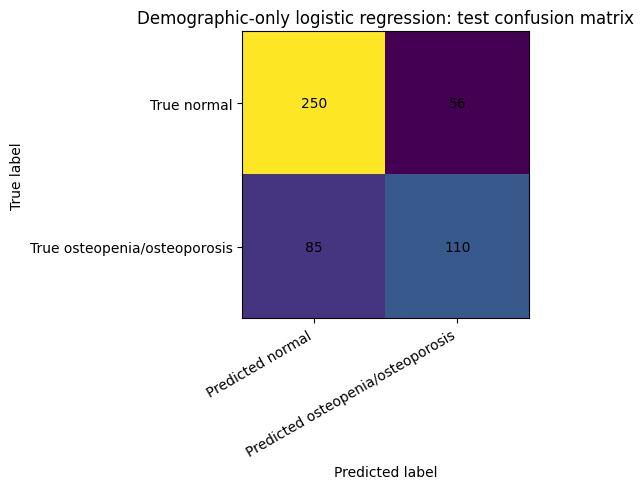

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(confusion_matrix_df.values)
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(confusion_matrix_df.columns, rotation=30, ha="right")
ax.set_yticklabels(confusion_matrix_df.index)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Demographic-only logistic regression: test confusion matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion_matrix_df.values[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


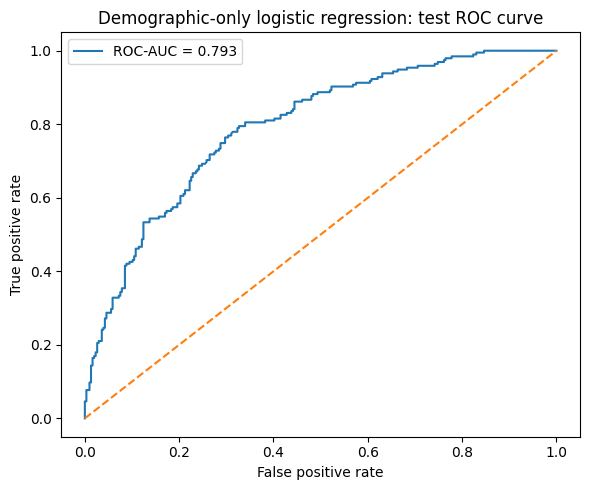

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Demographic-only logistic regression: test ROC curve")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Save outputs

In [11]:
baseline_predictions = pd.DataFrame(
    {
        "SEQN": test_seqn.to_numpy(),
        "y_true": y_test,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }
)

metrics_path = os.path.join(OUTPUT_DIR, "baseline_classification_test_metrics.csv")
predictions_path = os.path.join(OUTPUT_DIR, "baseline_classification_test_predictions.csv")
cv_path = os.path.join(OUTPUT_DIR, "baseline_classification_cv_metrics.csv")

baseline_results_df.to_csv(metrics_path, index=False)
baseline_predictions.to_csv(predictions_path, index=False)
cv_summary.to_csv(cv_path, index=False)

print("Saved:", metrics_path)
print("Saved:", predictions_path)
print("Saved:", cv_path)


Saved: .\baseline_classification_test_metrics.csv
Saved: .\baseline_classification_test_predictions.csv
Saved: .\baseline_classification_cv_metrics.csv


## 10. Optional comparison with CNN metrics

Run this cell only if `cnn_classification_test_metrics.csv` is available in the same folder.

This creates a compact comparison table between the demographic-only baseline and the CNN models.


In [13]:
cnn_metrics_path = os.path.join(OUTPUT_DIR, "cnn_classification_test_metrics.csv")

if os.path.exists(cnn_metrics_path):
    cnn_metrics = pd.read_csv(cnn_metrics_path)

    comparison = pd.concat(
        [
            baseline_results_df,
            cnn_metrics,
        ],
        ignore_index=True,
        sort=False,
    )

    comparison_columns = [
        "Model",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ]

    comparison = comparison[comparison_columns]
    comparison.to_csv(os.path.join(OUTPUT_DIR, "classification_baseline_vs_cnn_metrics.csv"), index=False)
    display(comparison)
else:
    print("CNN metrics file not found:", cnn_metrics_path)


,Model,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score,ROC-AUC
0,Demographic-only logistic regression,0.718563,0.564103,0.816993,0.662651,0.564103,0.609418,0.793162
1,ResNet,0.662675,0.215385,0.947712,0.724138,0.215385,0.332016,0.765695
2,VGG,0.712575,0.615385,0.774510,0.634921,0.615385,0.625000,0.779789


## 11. Manuscript-ready sentence template

After running the notebook, use the generated table to adapt this sentence:

> As a demographic-only reference model, logistic regression using sex, age, and body mass achieved a test accuracy of X, sensitivity of X, specificity of X, F1-score of X, and ROC-AUC of X. This baseline was included to contextualize the performance of the GAF-CNN models.
